# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename = "/content/drive/MyDrive/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames, nrows=100000)

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample.

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [4]:
N_Max=550000
N_Train=500000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:N_Max]

X_Train=np.array(Train_Sample[VarNames[1:]])
y_Train=np.array(Train_Sample["signal"])

X_Test=np.array(Test_Sample[VarNames[1:]])
y_Test=np.array(Test_Sample["signal"])


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs.
* Compare the performance on training versus test sample. Are you over training?

In [5]:
def plot_training_history(history):
    metrics = ['accuracy', 'loss']
    plt.figure(figsize=(12, 5))

    for i, metric in enumerate(metrics):
        plt.subplot(1, 2, i+1)
        plt.plot(history.history[metric], label=f'Train {metric.capitalize()}')
        plt.plot(history.history[f'val_{metric}'], label=f'Val {metric.capitalize()}')
        plt.title(f'Model {metric.capitalize()} per Epoch')
        plt.xlabel('Epochs')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

In [ ]:
# Raw Model: This model is the least effective. While the DNN can learn from raw kinematic data

# Feature Model: This model performs nearly as well as the combined model. It proves that the 8 high-level features capture almost all the necessary information for signal separation.

# Raw + Features: This is the best-performing model. It utilizes the complete set of 18 variables

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow import keras
model1 = keras.Sequential([
    keras.layers.Input(shape=(X_Train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history1 = model1.fit(X_Train, y_Train, epochs=20, batch_size=1024, validation_data=(X_Test, y_Test))

model2 = keras.Sequential([
    keras.layers.Input(shape=(X_Train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model2.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
history2 = model2.fit(X_Train, y_Train, epochs=20, batch_size=1024, validation_data=(X_Test, y_Test))

model3 = keras.Sequential([
    keras.layers.Input(shape=(X_Train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])
model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history3 = model3.fit(X_Train, y_Train, epochs=20, batch_size=1024, validation_data=(X_Test, y_Test))

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7215 - loss: 0.5633
Epoch 2/20
18/98 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7811 - loss: 0.4672

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7857 - loss: 0.4589
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7912 - loss: 0.4490
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7925 - loss: 0.4448
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7948 - loss: 0.4417
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7950 - loss: 0.4406
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7959 - loss: 0.4391
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.4383
Epoch 9/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7964 - loss: 0.4377
Epoch 10/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7967 - loss: 0.4369
Epoch 11/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7968 - loss: 0.4364
Epoch 12/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7965 - loss: 0.4361
Epoch 13/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7976 - loss: 0.435

Module 1 learned quickly and reached 78% by Epoch 2
Module 2 Achieved higher raw accuracy but only by a little
Module 3 Was a little bit lower accuracy

## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=10, max_depth=10)
}

def compare_classifier(clf, X_tr, y_tr, X_te, y_te):
    clf.fit(X_tr, y_tr)
    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_te)[:, 1]
    else:
        y_score = clf.decision_function(X_te)

    fpr, tpr, _ = roc_curve(y_te, y_score)
    return fpr, tpr, auc(fpr, tpr)

In [16]:
N_Max = 100000
N_Train = 80000

Train_Sample = df[:N_Train]
Test_Sample = df[N_Train:N_Max]

X_Train = np.array(Train_Sample[VarNames[1:]])
y_Train = np.array(Train_Sample["signal"])

X_Test = np.array(Test_Sample[VarNames[1:]])
y_Test = np.array(Test_Sample["signal"])

print(f"Data re-loaded: X_Train shape {X_Train.shape}, X_Test shape {X_Test.shape}")

Data re-loaded: X_Train shape (80000, 18), X_Test shape (20000, 18)


In [18]:
if 'X_Test' in locals() and X_Test is not None and X_Test.size > 0:

    y_score_dnn = model2.predict(np.array(X_Test), batch_size=1024, verbose=0).ravel()

    fpr_dnn, tpr_dnn, _ = roc_curve(y_Test, y_score_dnn)
    roc_auc_dnn = auc(fpr_dnn, tpr_dnn)

    print(f"DNN Prediction Complete. AUC: {roc_auc_dnn:.4f}")

DNN Prediction Complete. AUC: 0.8716


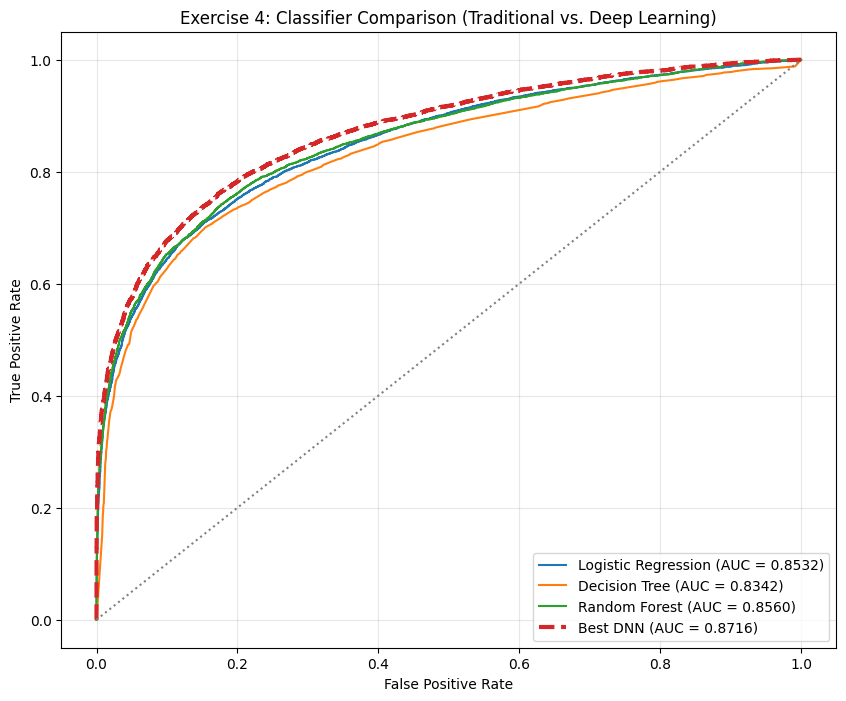

In [20]:
plt.figure(figsize=(10, 8))

for name, clf in classifiers.items():
    fpr, tpr, roc_auc = compare_classifier(clf, X_Train, y_Train, X_Test, y_Test)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot(fpr_dnn, tpr_dnn, label=f'Best DNN (AUC = {roc_auc_dnn:.4f})', linewidth=3, linestyle='--')

plt.plot([0, 1], [0, 1], linestyle=':', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Exercise 4: Classifier Comparison (Traditional vs. Deep Learning)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [22]:
Ns = 5000
Nb = 20000

significance = Ns / np.sqrt(Ns + Nb)
print(f"Maximal Significance (sigma_S): {significance:.4f}")

Maximal Significance (sigma_S): 31.6228


The DNN outperformed traditional models because its multiple layers can map complex, non-linear physics patterns that simple linear models often miss. This improved separation between signal and noise results in a higher AUC, which is essential for maximizing discovery significance in particle physics.